In [9]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import openpyxl as xl
from openpyxl.styles import Font
from scipy import optimize 
from scipy import integrate
import copy
import os

In [ ]:
#Coletando dados 

df = pd.read_excel(r'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Para\3-Clupeiformes\R.xlsx')


df_especies = pd.DataFrame(df[['Ano',"Corvina_art", "Corvina_ind", "Pesc_amarela_art", "Pesc_amarela_ind", "Pesc_cambucu_art", "Pesc_cambucu_ind", "Pescadinha_art", "Pescadinha_ind", "Pesc_branca_art"]])
inicio_pesca = pd.read_excel(r'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Para\3-Clupeiformes\I.xlsx')



lista_de_pesca = [] #lista onde ficam os arrays com as pescas de cada especias
lista_de_anos_Para_prever = []
lista_anos_com_dados = []

especies = df_especies.drop('Ano',axis=1).columns.to_numpy()

for k in range(len(especies)):
    dados = df_especies[['Ano',especies[k]]].dropna()

    #achando os anos Para\ prever da especie
    anos_Para_prever = []
    for i in range(len(inicio_pesca.iloc[:,0])):
        if inicio_pesca.loc[i,'Variavel'] == especies[k]:
            inicio = inicio_pesca.loc[i,'Ano_inicio']
            fim = inicio_pesca.loc[i,'Ano_final']
    anos = np.arange(inicio,fim+1)
    for i in anos:
        if pd.isnull(df_especies.loc[i-1950,especies[k]])==True:
            anos_Para_prever.append(i)

    anos_Para_prever = np.array(anos_Para_prever)   
    print(anos_Para_prever)
    lista_de_anos_Para_prever.append(anos_Para_prever)

    anos_com_dados = dados["Ano"].values
    lista_anos_com_dados.append(anos_com_dados)

    todos_anos = np.concatenate((anos_Para_prever, anos_com_dados))
    todos_anos.sort()
    
    pesca = dados[especies[k]].values
    lista_de_pesca.append(pesca)
    print(dados.head())

[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1965
 1969 1974 1975 1990 1991 1992 1993 1994 1995 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022]
     Ano  Corvina_art
13  1963   292.844340
14  1964   260.125791
16  1966   648.375948
17  1967   561.410091
18  1968  2062.130449
[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1965
 1969 1974 1975 1982 1983 1984 1985 1990 1991 1992 1993 1994 1995 2005
 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020
 2021 2022]
     Ano  Corvina_ind
13  1963     7.239342
14  1964     6.145640
16  1966    13.981797
17  1967    11.586687
18  1968   135.665551
[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1965
 1969 1974 1975 1990 1991 1992 1993 1994 1995 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022]
     Ano  Pesc_amarela_art
13  1963         54.387203
14  1964         50.561711
16  1966        136.732276
17  1967       

In [11]:
#Normalização dos dados
lista_pesca_norm=[]  #lista com as pescas normalizads Para\ cada especie
lista_pesca_mean=[]  #listas Para\ aplicar a inversa da normalização
lista_pesca_std=[]

lista_ano_mean=[]
lista_ano_std=[]
lista_anos_com_dados_norm=[]
lista_de_anos_Para_prever_norm=[]

for k in range(len(especies)):
    ano_mean = np.mean(lista_anos_com_dados[k])
    ano_std = np.std(lista_anos_com_dados[k])
    anos_Para_prever_norm = (lista_de_anos_Para_prever[k] - ano_mean)/ano_std
    anos_com_dados_norm = (lista_anos_com_dados[k] - ano_mean)/ano_std
    
    lista_anos_com_dados_norm.append(anos_com_dados_norm)
    lista_ano_mean.append(ano_mean)
    lista_ano_std.append(ano_std)
    lista_de_anos_Para_prever_norm.append(anos_Para_prever_norm)

    pesca_mean = np.mean(lista_de_pesca[k])
    pesca_std = np.std(lista_de_pesca[k])
    pesca_norm = (lista_de_pesca[k] - pesca_mean)/pesca_std

    lista_pesca_norm.append(pesca_norm)  
    lista_pesca_mean.append(pesca_mean)  
    lista_pesca_std.append(pesca_std)

In [ ]:
#Criação das pastas onde serão armazenados os pesos
for esp in especies:
    folder_path = rf'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Para\3-Clupeiformes\/Peso_{esp}'
    if not os.path.exists(folder_path):
        os.mkdir(folder_path) 


#Função Para\ fazer o Fit do modelo e salvar seus pesos Para\ cada especie
def Interpolações(lista_anos_com_dados_norm,
                       lista_pesca_norm,
                       lista_de_epocas,
                       lista_de_otimizadores,
                       lista_de_overwrite,
                       especies):
    
    model = keras.Sequential([layers.Dense(96,activation='leaky_relu',input_shape=(1,)),
                                 layers.Dense(32,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(96,activation='leaky_relu'),
                                 layers.Dense(112,activation='leaky_relu'),
                                 layers.Dense(1,activation='linear')])
    
    lista_de_loss=[]
    for k in range(len(especies)):
        opt =  lista_de_otimizadores[k]            #keras.optimizers.Nadam(learning_rate=0.001)
        model.compile(optimizer=opt, loss='mse')
        
        
        history = model.fit(lista_anos_com_dados_norm[k],lista_pesca_norm[k], epochs=lista_de_epocas[k], verbose=0)
        lista_de_loss.append(history.history['loss'])

        
        model.save_weights(rf'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Para\3-Clupeiformes/Peso_{especies[k]}/.weights.h5', overwrite=lista_de_overwrite[k])
    return model,lista_de_loss


In [13]:
#Fit do modelo
Nadam= keras.optimizers.Nadam(learning_rate=0.001)
Adam= keras.optimizers.Adam(learning_rate=0.001)

lista_de_epocas=[250,250,150,150,150,150,150,150,150,150]
lista_de_otimizadores=[Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam]
lista_de_overwrite = [True,True,True,True,True,True,True,True,True,True]
model,lista_de_loss = Interpolações(lista_anos_com_dados_norm,
                                         lista_pesca_norm,
                                         lista_de_epocas,
                                         lista_de_otimizadores,
                                         lista_de_overwrite,
                                         especies)

c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Previsões Para\ cada especie
lista_de_previsoes=[]
lista_fits=[]

p = np.linspace(-2,2,50)
for k in range(len(especies)):
    
    model.load_weights(rf'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Para\3-Clupeiformes/Peso_{especies[k]}/.weights.h5')

    prev_ausentes = model.predict(lista_de_anos_Para_prever_norm[k])*lista_pesca_std[k] + lista_pesca_mean[k]
    fit = model.predict(p)*lista_pesca_std[k] + lista_pesca_mean[k]
    #Colocando valores negativos Para\ 0 e proporções no maximo 1
    for i in range(len(prev_ausentes)):
        if prev_ausentes[i]<0:
            prev_ausentes[i]=0


    lista_de_previsoes.append(prev_ausentes)
    lista_fits.append(fit)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


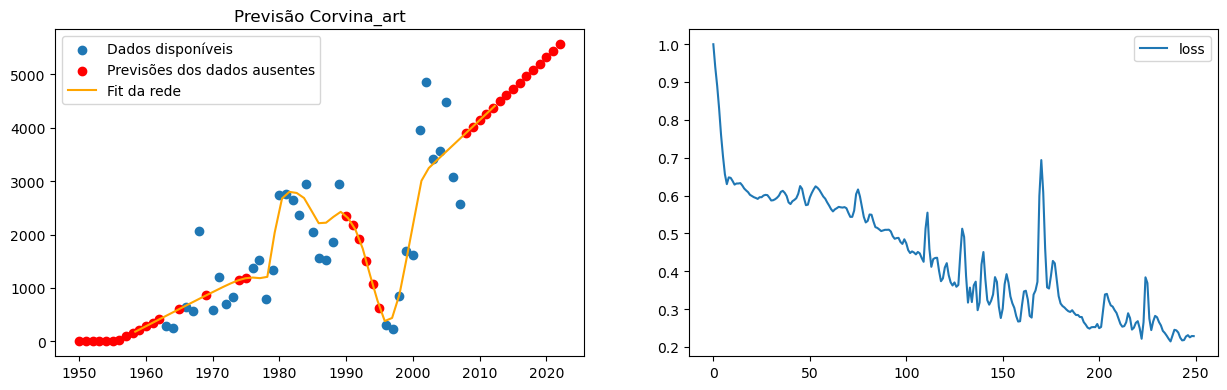

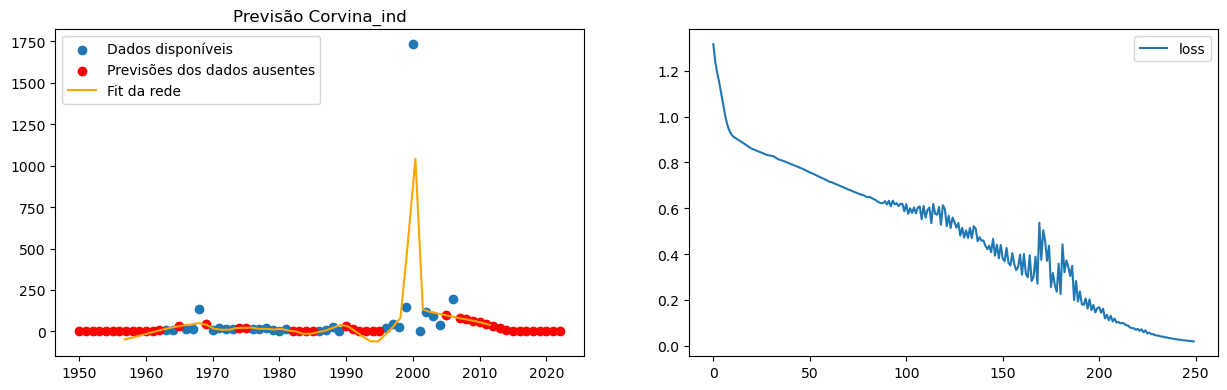

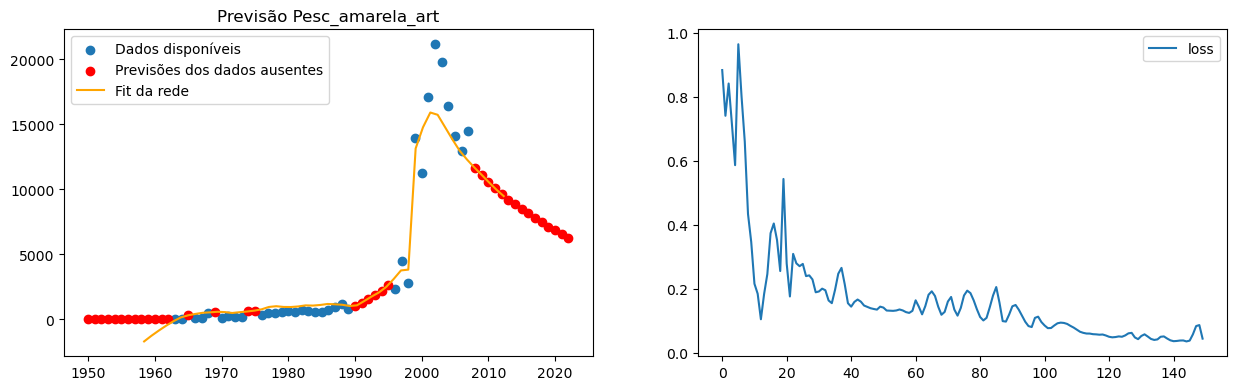

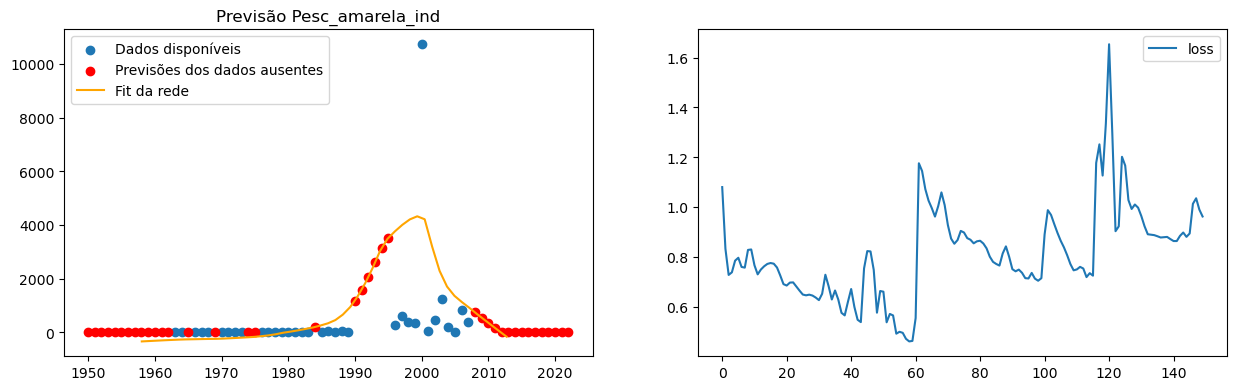

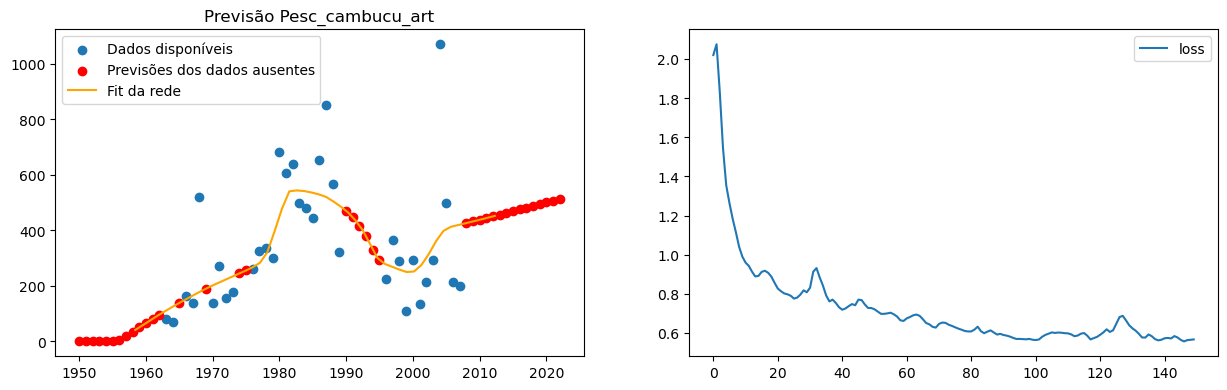

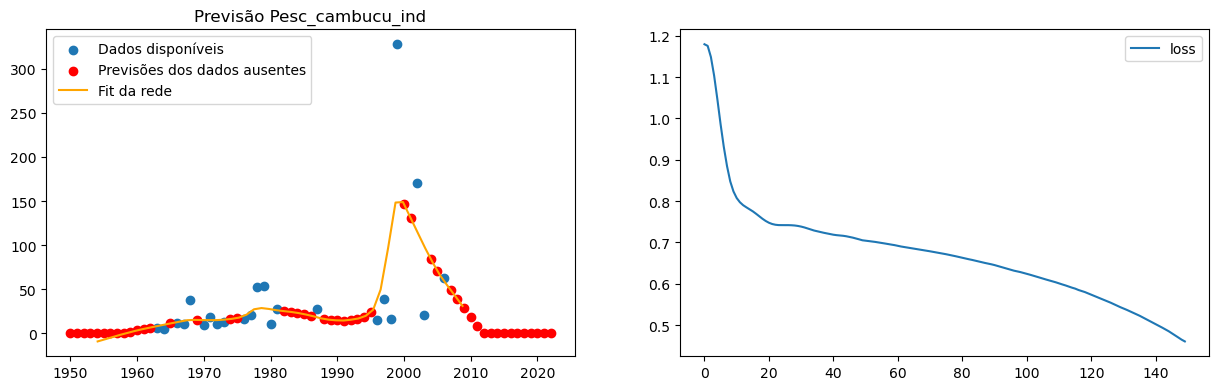

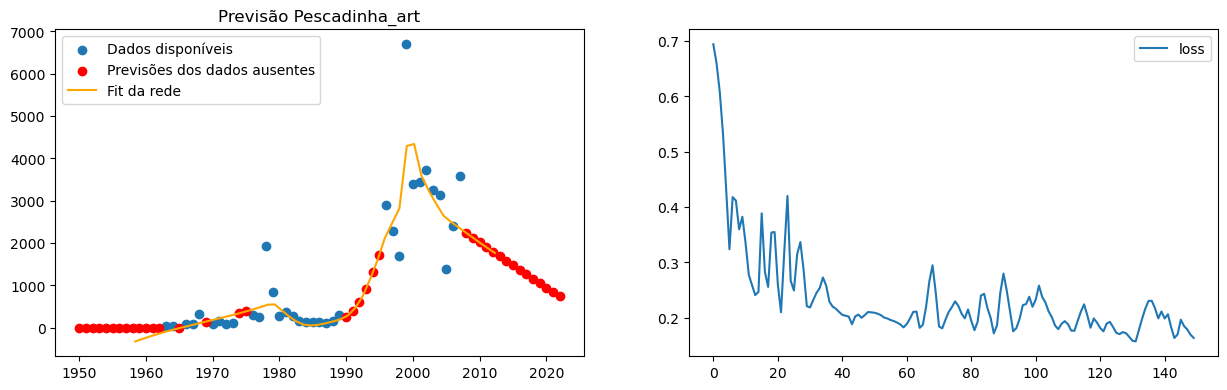

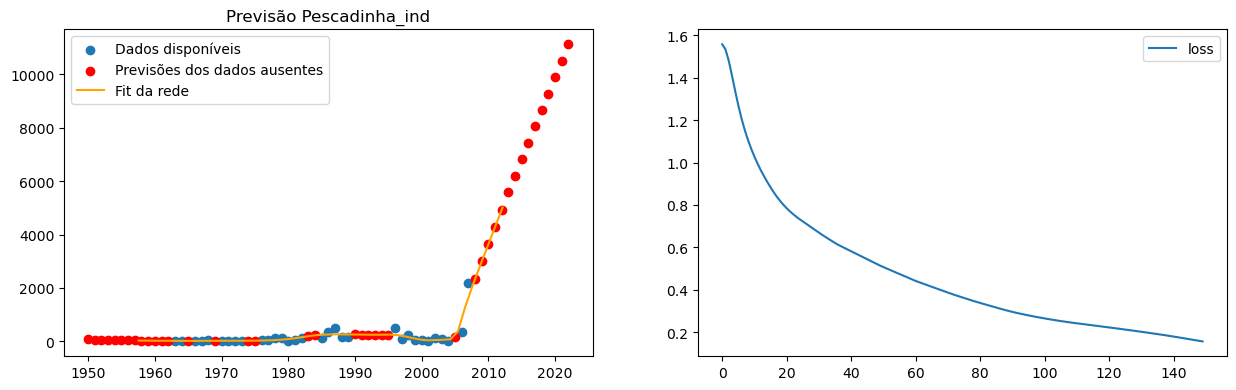

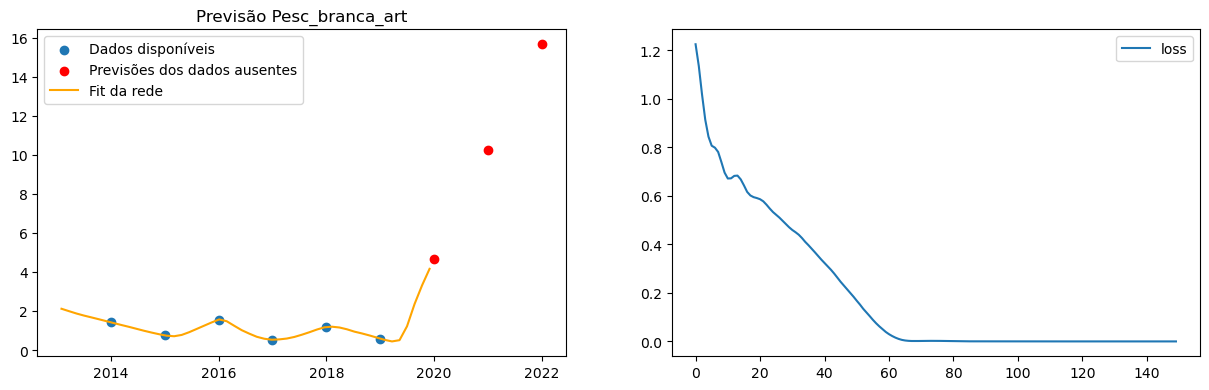

In [15]:
#Plot das previsoes e loss Para\ cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_anos_com_dados[k],lista_de_pesca[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_de_anos_Para_prever[k],lista_de_previsoes[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*lista_ano_std[k] + lista_ano_mean[k],lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [16]:
#Adicionando aleatoriedade
lista_de_previsoes_rd = copy.deepcopy(lista_de_previsoes)

#Distribuição normal
def normal(x,med,std):
    return (1/(std*np.sqrt(2*np.pi)))*np.exp(-0.5*(((x-med)/std)**2))

#Função Para\ calcular o intervalo de confiança de 90%
def g(k,med,std):
    dx = ((med+k*std)-(med-k*std))/10
    x=[]
    y=[]
    for i in range(11):
        x.append((med-k*std)+i*dx)
        y.append(normal((med-k*std)+i*dx,med,std))
    return integrate.simpson(y,x=x) - 0.90


#Dataframe com os dados reconstruídos
df_prev = df[['Ano',"Corvina_art", "Corvina_ind", "Pesc_amarela_art", "Pesc_amarela_ind", "Pesc_cambucu_art", "Pesc_cambucu_ind", "Pescadinha_art", "Pescadinha_ind", "Pesc_branca_art"]]
for k in range(len(especies)):
    for i in range(len(lista_de_anos_Para_prever[k])):
        df_prev.loc[lista_de_anos_Para_prever[k][i]-1950,especies[k]] = lista_de_previsoes[k][i,0]

for k in range(len(especies)):
    for i in range(len(lista_de_anos_Para_prever[k])):

        #Desvios padrao(5 anos)
        
        #anos_considerados=[]
        valores_considerados=[]
        t=-2
        
        if lista_de_anos_Para_prever[k][i]-1950 -2 <0  or pd.isnull(df_prev.loc[lista_de_anos_Para_prever[k][i]-1950-2,especies[k]])==True:
            t=-1
        if lista_de_anos_Para_prever[k][i]-1950 -1 <0  or pd.isnull(df_prev.loc[lista_de_anos_Para_prever[k][i]-1950-1,especies[k]])==True:
            t=0            
        if lista_de_anos_Para_prever[k][i]-1950 -2+4 > 72  or pd.isnull(df_prev.loc[lista_de_anos_Para_prever[k][i]-1950-2+4,especies[k]])==True:
            t=-3
        if lista_de_anos_Para_prever[k][i]-1950 -3+4 > 72  or pd.isnull(df_prev.loc[lista_de_anos_Para_prever[k][i]-1950-3+4,especies[k]])==True:
            t=-4    

        while len(valores_considerados)<5:   
                #anos_considerados.append(lista_de_anos_Para\_prever[k][i]+t)
                valores_considerados.append(df_prev.loc[lista_de_anos_Para_prever[k][i]-1950+t,especies[k]])
                t+=1
        
        #print(lista_de_anos_Para\_prever[k][i],valores_considerados)
        std = np.std(np.array(valores_considerados))
        med = lista_de_previsoes[k][i,0]
        if std!=0:
          #Raiz da função g(k) pelo método da secante
          raiz = optimize.newton(g,1,args=(med,std))
          
          #Gerando valor aleatorio Para\ a previsão(se houver valores positivos no intervalo)
          prev_min = med - std*raiz
          prev_max = med + std*raiz
          if prev_max>0:
              rd=-1
              #A aleatorização é refeita se o resultado for negativo ou zero
              while rd<=0:
                  rd = np.random.choice(np.linspace(prev_min,prev_max,50))
          else:
              print('A espécie',especies[k],'tem valor(es) negativo(s)')
          lista_de_previsoes_rd[k][i,0]=rd

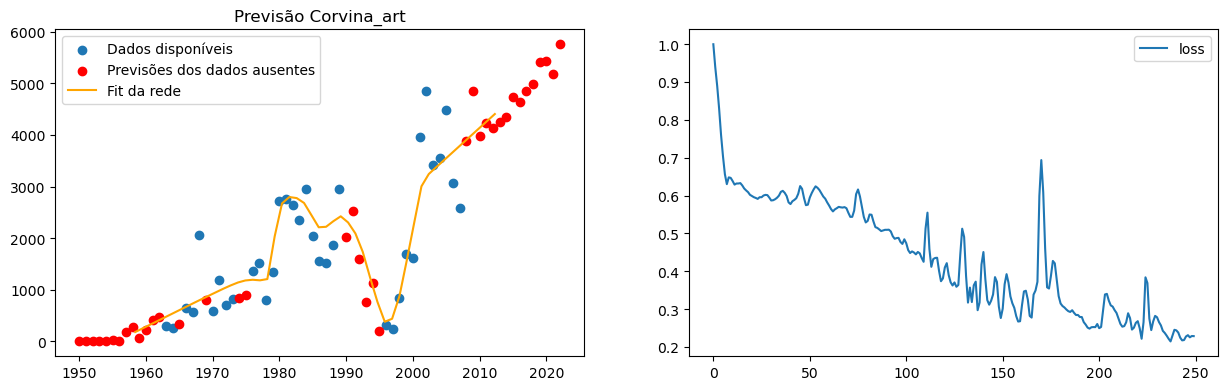

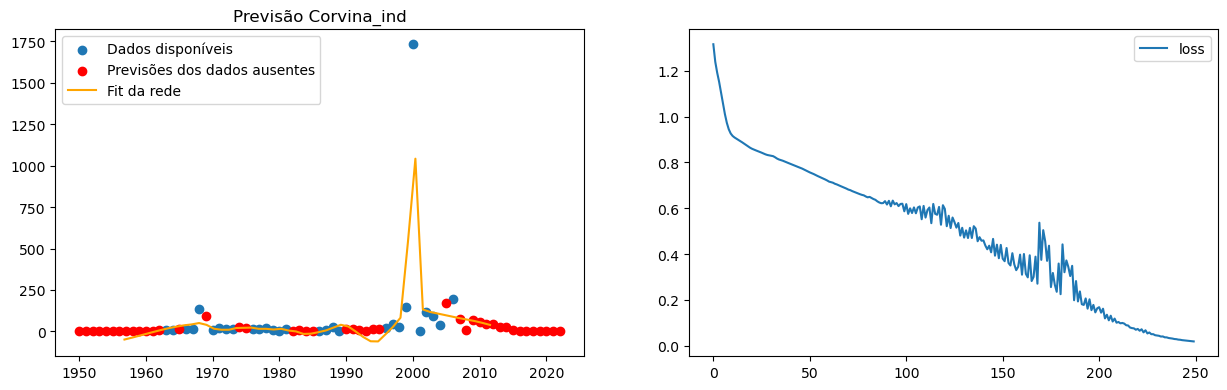

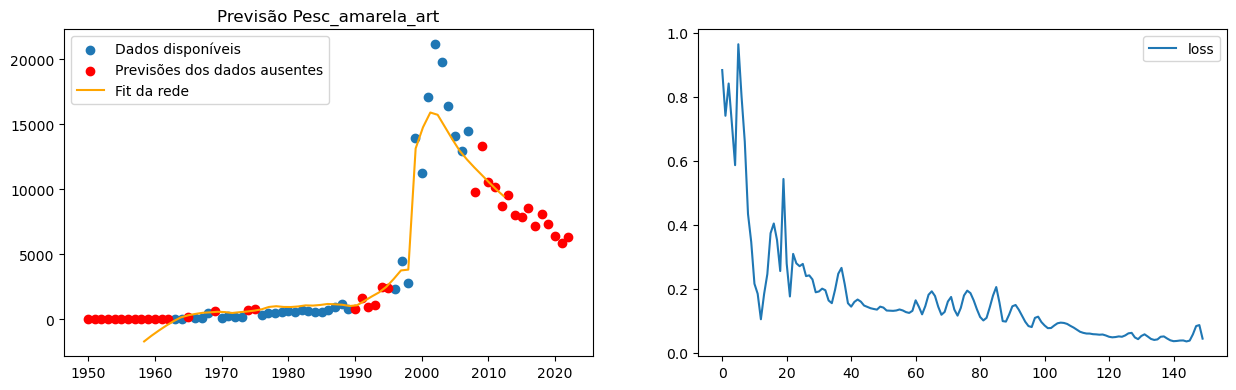

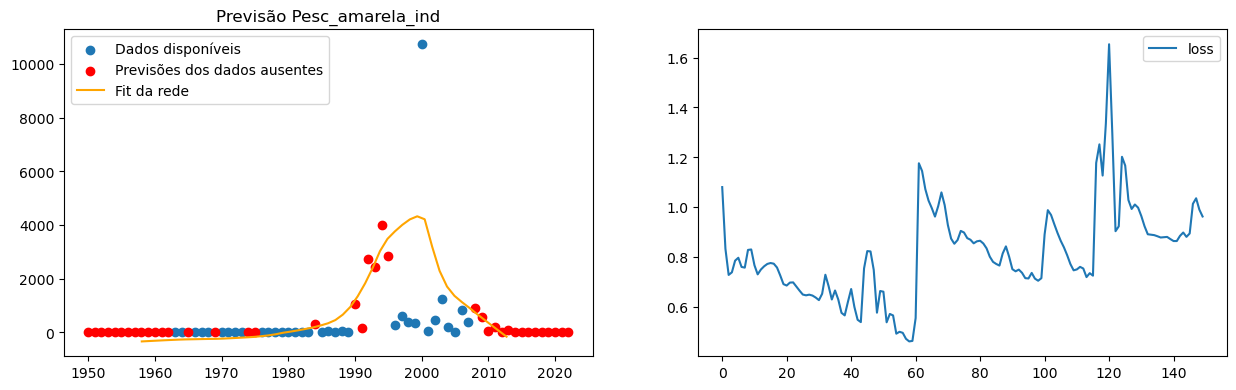

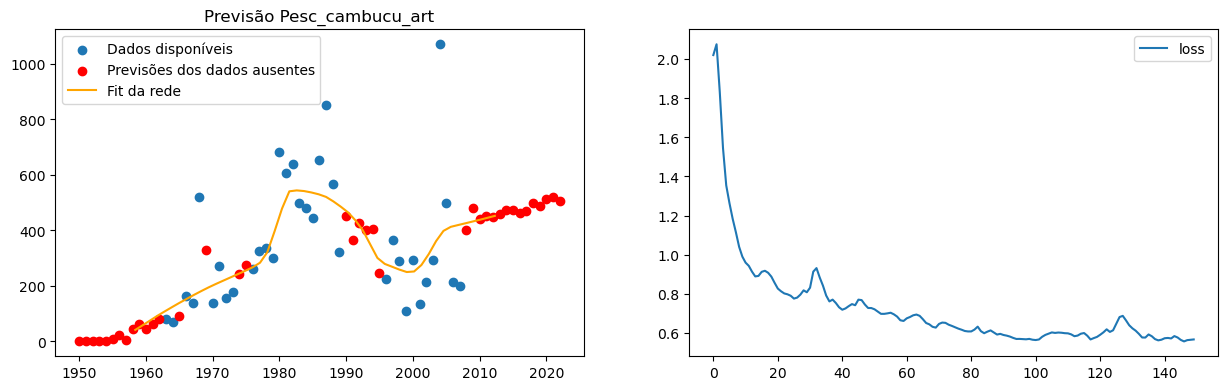

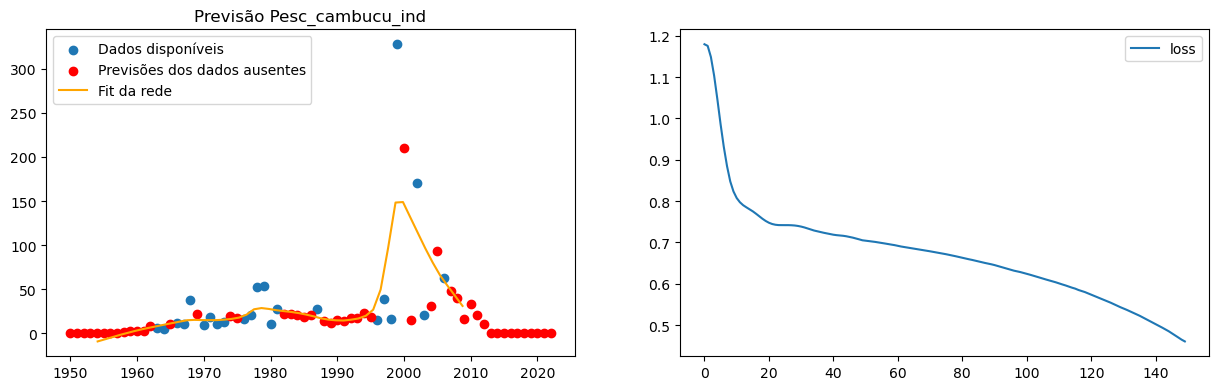

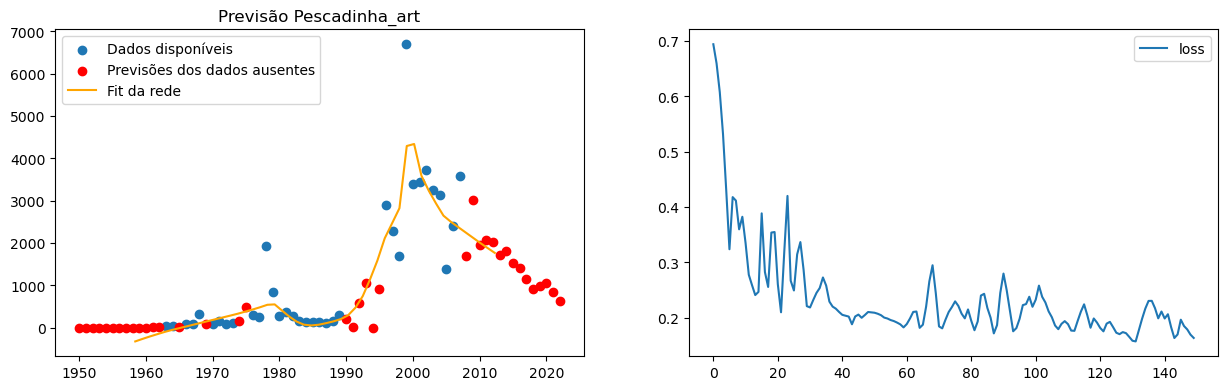

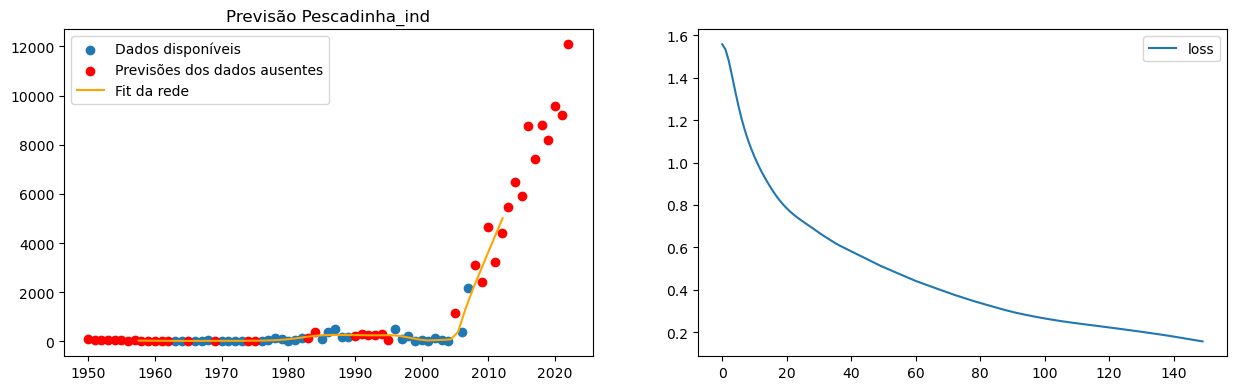

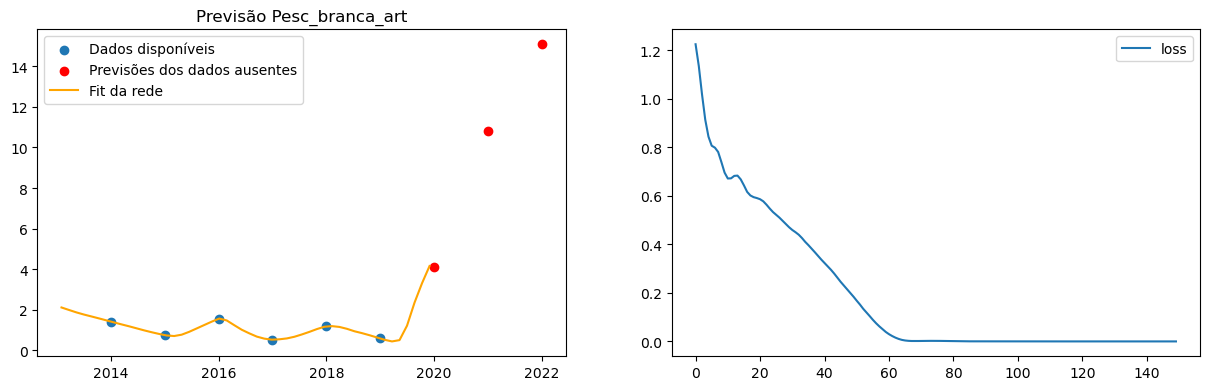

In [17]:
#Plot das previsoes e loss Para\ cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_anos_com_dados[k],lista_de_pesca[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_de_anos_Para_prever[k],lista_de_previsoes_rd[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*lista_ano_std[k] + lista_ano_mean[k],lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [18]:
#Dicionario dos indices das espécie Para\ prever  (Para\ usar o nome da coluna no openpyxl) 
todas_colunas=df.columns.to_numpy()
dic_especies={}
for k in range(len(especies)):
    for i in range(len(todas_colunas)):
        if especies[k]==todas_colunas[i]:
            dic_especies[especies[k]]=i+1 #Índices do openpyxl
            break

In [ ]:
#ws com os dados preenchidos e coloridos(todos vermelhos)
wb = xl.load_workbook(r'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Para\3-Clupeiformes\R.xlsx')
ws = wb.active

for k in range(len(especies)):
    for i in range(len(lista_de_anos_Para_prever[k])):
        celula=ws.cell(lista_de_anos_Para_prever[k][i]-1950+2 , dic_especies[especies[k]])
        celula.value = lista_de_previsoes_rd[k][i,0]
        celula.font = Font(color='FFFF0000',name='Calibri')


wb.save('Interpolações.xlsx')


In [21]:
   ###Caso o openpyxl não coloque todos os valores###



df_prev = df[['Ano',"Corvina_art", "Corvina_ind", "Pesc_amarela_art", "Pesc_amarela_ind", "Pesc_cambucu_art", "Pesc_cambucu_ind", "Pescadinha_art", "Pescadinha_ind", "Pesc_branca_art"]]
for k in range(len(especies)):
    for i in range(len(lista_de_anos_Para_prever[k])):
        df_prev.loc[lista_de_anos_Para_prever[k][i]-1950,especies[k]] = lista_de_previsoes_rd[k][i,0]
df_prev.to_excel('Interpol pandas.xlsx')